In [ ]:
import csv
import pandas as pd
from google.colab import files

# Data manipulation
import pandas as pd
import numpy as np

# Statistical analysis
import statsmodels.api as sm
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
uploaded = files.upload()

Saving Data Bersih_Regresi.csv to Data Bersih_Regresi.csv


In [ ]:
rg = pd.read_csv("Data Bersih_Regresi.csv")
rg

,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score
0,-0.1817,0.5921,0.3478,0.2727,1.0310
1,-0.1806,0.6244,0.1943,0.2912,0.9293
2,-0.2670,0.5252,0.0811,0.3226,0.6619
3,-0.2564,0.5998,0.3103,0.3258,0.9795
4,-0.1808,0.5149,0.0604,0.3265,0.7210
...,...,...,...,...,...
1166,2.5175,0.4250,0.1898,3.5440,6.6763
1167,2.8335,0.4275,0.0796,3.2158,6.5564
1168,2.3790,0.4487,0.0714,3.6915,6.5906
1169,2.4883,0.5276,0.2387,3.0053,6.2599


In [ ]:
data = rg[["Z_Score_X1", "Z_Score_X2", "Z_Score_X3", "Z_Score_X4","Z_Score"]]
data

,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score
0,-0.1817,0.5921,0.3478,0.2727,1.0310
1,-0.1806,0.6244,0.1943,0.2912,0.9293
2,-0.2670,0.5252,0.0811,0.3226,0.6619
3,-0.2564,0.5998,0.3103,0.3258,0.9795
4,-0.1808,0.5149,0.0604,0.3265,0.7210
...,...,...,...,...,...
1166,2.5175,0.4250,0.1898,3.5440,6.6763
1167,2.8335,0.4275,0.0796,3.2158,6.5564
1168,2.3790,0.4487,0.0714,3.6915,6.5906
1169,2.4883,0.5276,0.2387,3.0053,6.2599


In [ ]:
data.corr()

,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score
Z_Score_X1,1.000000,0.145300,0.086944,0.029769,0.276328
Z_Score_X2,0.145300,1.000000,0.523325,-0.032589,0.164646
Z_Score_X3,0.086944,0.523325,1.000000,-0.076640,0.081626
Z_Score_X4,0.029769,-0.032589,-0.076640,1.000000,0.953438
Z_Score,0.276328,0.164646,0.081626,0.953438,1.000000


# Feature Selection

In [ ]:
# Variabel Independen yang digunakan adalah Z_Score_X1, Z_Score_X2, Z_Score_X3, Z_Score_X4
# Variabel Dependen yang digunakan adalah Z_Score

X = rg[["Z_Score_X1", "Z_Score_X2", "Z_Score_X3", "Z_Score_X4"]]
y = rg["Z_Score"]

# Splitting Data

In [ ]:
# Dataset dibagi menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pemodelan

In [ ]:
# Tambahkan konstanta (intercept)
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Pemodelan
model = sm.OLS(y_train, X_train_const).fit()

# Evaluasi Model

In [ ]:
# --- Prediksi ---
y_pred = model.predict(X_test_const)   # hasil prediksi model
y_actual = y_test                      # nilai aktual (target sebenarnya)


# --- Evaluasi dasar ---
r2 = model.rsquared
adj_r2 = model.rsquared_adj

# --- Evaluasi error ---
MAE = mean_absolute_error(y_actual, y_pred)
MSE = mean_squared_error(y_actual, y_pred)
RMSE = np.sqrt(MSE)
MAPE = mean_absolute_percentage_error(y_actual, y_pred) * 100  # dalam persen

# --- Tampilkan hasil evaluasi ---
print("\n=== Evaluasi Model Regresi ===")
print(f"R-squared: {r2:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")
print(f"MAE (Mean Absolute Error): {MAE:.4f}")
print(f"MSE (Mean Squared Error): {MSE:.4f}")
print(f"RMSE (Root Mean Squared Error): {RMSE:.4f}")
print(f"MAPE (Mean Absolute Percentage Error): {MAPE:.2f}%")
print("----------------------------------------------")

# --- Ringkasan model ---
print("\nRingkasan Model:")
print(model.summary())


=== Evaluasi Model Regresi ===
R-squared: 1.0000
Adjusted R-squared: 1.0000
MAE (Mean Absolute Error): 0.0000
MSE (Mean Squared Error): 0.0000
RMSE (Root Mean Squared Error): 0.0001
MAPE (Mean Absolute Percentage Error): 0.01%
----------------------------------------------

Ringkasan Model:
                            OLS Regression Results                            
Dep. Variable:                Z_Score   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.411e+12
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        15:38:19   Log-Likelihood:                 7692.0
No. Observations:                 936   AIC:                        -1.537e+04
Df Residuals:                     931   BIC:                        -1.535e+04
Df Model:                           4                                      

## Kesimpulan Evaluasi Model Regresi

Berdasarkan hasil OLS Regression dan metrik evaluasi model, berikut ringkasannya:

### 1. Kualitas Model
- **R-squared = 1.0000** dan **Adjusted R-squared = 1.0000**  
  → Model menjelaskan hampir **100% variasi Z_Score**. Sangat baik.
- **MAE = 0.0000, MSE = 0.0000, RMSE = 0.0001, MAPE = 0.01%**  
  → Prediksi model hampir **sama persis dengan nilai aktual**.  
  → Visualisasi line chart antara nilai aktual dan prediksi akan menempel hampir sempurna.

### 2. Signifikansi Variabel Independen
| Variabel | Koefisien | t-value    | P-value | Interpretasi |
|----------|------------|------------|---------|--------------|
| Z_Score_X1 | 1.0000    | 7.18e+05   | 0.000   | Signifikan, berkontribusi pada prediksi Z_Score |
| Z_Score_X2 | 1.0000    | 3.48e+05   | 0.000   | Signifikan, berkontribusi pada prediksi Z_Score |
| Z_Score_X3 | 1.0000    | 1.94e+05   | 0.000   | Signifikan, berkontribusi pada prediksi Z_Score |
| Z_Score_X4 | 1.0000    | 2.98e+06   | 0.000   | Paling dominan, pengaruh sangat kuat terhadap Z_Score |

> Catatan: Nilai t yang sangat besar dan p-value < 0.05 menunjukkan semua variabel independen **signifikan secara statistik**.

### 3. Kesimpulan Umum
- Model regresi **sangat baik** dan mampu memprediksi Z_Score dengan **akurat tinggi**.  
- Semua variabel independen signifikan, dengan **Z_Score_X4 menjadi variabel dominan**.  


In [ ]:
#Evaluasi Tambahan: Log-Likelihood, AIC, BIC, Pseudo-R²
log_likelihood = model.llf
aic = model.aic
bic = model.bic

try:
    pseudo_r2 = 1 - (model.llf / model.llnull)
except:
    pseudo_r2 = np.nan

print("\n=== Evaluasi Tambahan Model Regresi ===")
print(f"Log-Likelihood : {log_likelihood:.4f}")
print(f"AIC             : {aic:.4f}")
print(f"BIC             : {bic:.4f}")
if not np.isnan(pseudo_r2):
    print(f"Pseudo R² (McFadden) : {pseudo_r2:.4f}")
else:
    print("Pseudo R² (McFadden) : Tidak tersedia untuk model ini")

# Interpretasi Otomatis Hasil Evaluasi Model

print("\n=== Interpretasi Evaluasi Model ===")

# Interpretasi Log-Likelihood
if log_likelihood > 0:
    print(f"➡️ Nilai Log-Likelihood sebesar {log_likelihood:.4f} menunjukkan bahwa model memiliki kemungkinan yang baik dalam menyesuaikan data.")
else:
    print(f"⚠️ Nilai Log-Likelihood sebesar {log_likelihood:.4f} relatif rendah, menunjukkan model masih dapat ditingkatkan.")

# Interpretasi AIC & BIC
print(f"➡️ Nilai AIC = {aic:.4f} dan BIC = {bic:.4f}.")
print("Semakin kecil nilai AIC dan BIC, semakin efisien model dalam menyesuaikan data tanpa overfitting.")

# Interpretasi Pseudo-R² (McFadden)
if not np.isnan(pseudo_r2):
    if pseudo_r2 < 0.2:
        interpret_r2 = "cukup lemah"
    elif pseudo_r2 < 0.4:
        interpret_r2 = "sedang"
    else:
        interpret_r2 = "kuat"
    print(f"➡️ Nilai Pseudo-R² (McFadden) sebesar {pseudo_r2:.4f}, yang berarti kekuatan model dalam menjelaskan data tergolong {interpret_r2}.")
else:
    print("ℹ️ Pseudo-R² (McFadden) tidak dapat dihitung untuk model OLS ini.")

# Kesimpulan umum
print("\n=== Kesimpulan Umum Evaluasi ===")
if (aic < 200 and bic < 200) or (pseudo_r2 >= 0.3):
    print("✅ Model memiliki kecocokan yang cukup baik dan dapat digunakan untuk analisis prediksi Z-Score.")
else:
    print("⚠️ Model masih perlu penyempurnaan, misalnya dengan menambah atau memodifikasi variabel independen.")



=== Evaluasi Tambahan Model Regresi ===
Log-Likelihood : 7692.0064
AIC             : -15374.0128
BIC             : -15349.8048
Pseudo R² (McFadden) : Tidak tersedia untuk model ini

=== Interpretasi Evaluasi Model ===
➡️ Nilai Log-Likelihood sebesar 7692.0064 menunjukkan bahwa model memiliki kemungkinan yang baik dalam menyesuaikan data.
➡️ Nilai AIC = -15374.0128 dan BIC = -15349.8048.
Semakin kecil nilai AIC dan BIC, semakin efisien model dalam menyesuaikan data tanpa overfitting.
ℹ️ Pseudo-R² (McFadden) tidak dapat dihitung untuk model OLS ini.

=== Kesimpulan Umum Evaluasi ===
✅ Model memiliki kecocokan yang cukup baik dan dapat digunakan untuk analisis prediksi Z-Score.


## Evaluasi Tambahan ##



1. **Nilai Log-Likelihood = 7692.0064** : Nilai ini menunjukkan tingkat kemungkinan model dalam menyesuaikan data yang digunakan. Semakin tinggi nilai log-likelihood, semakin baik model dalam menggambarkan hubungan antara variabel independen dan dependen.

2. **Nilai AIC (Akaike Information Criterion) = -15374.0128** : AIC digunakan untuk menilai efisiensi model dengan mempertimbangkan kompleksitasnya. Nilai AIC yang lebih kecil menunjukkan model yang lebih baik karena mampu menyesuaikan data tanpa menyebabkan overfitting.
3. **Nilai BIC (Bayesian Information Criterion) = -15349.8048** : Sama halnya dengan AIC, BIC digunakan untuk menilai seberapa baik model menyesuaikan data. Nilai BIC yang lebih rendah menandakan model yang lebih efisien dan sesuai dengan data.
4. **Pseudo R² (McFadden)** : Nilai ini tidak tersedia karena model yang digunakan merupakan model OLS (Ordinary Least Squares), bukan model regresi logistik yang biasanya menggunakan ukuran tersebut.


# Kesimpulan

Bisa disimpulkan bahwa model regresi mewakili hubungan antar variabel dengan baik dan efisien berdasarkan nilai log-likelihood yang tinggi serta nilai AIC dan BIC yang rendah. Oleh karena itu, model ini layak digunakan untuk analisis prediksi Z-Score.




# Uji Asumsi Normalitas, Multikolinearitas, Heteroskedastisitas dan Autokorelasi

## Uji Normalitas Residu (Uji Jarque-Bera)

### Tujuan
Uji normalitas residual bertujuan untuk mengetahui apakah **residual (selisih antara nilai aktual dan prediksi)** dari model regresi berdistribusi **normal**.  
Asumsi normalitas penting karena:  
- Menjamin hasil estimasi parameter regresi (**koefisien β**) valid secara statistik.  
- Memastikan uji **t** dan **F** dapat digunakan dengan tepat untuk menguji signifikansi model.  

---

### Hipotesis
- **H₀** : Residual berdistribusi normal  
- **H₁** : Residual tidak berdistribusi normal

---

 ### 📊 Kriteria Penilaian

| Nilai p-value | Interpretasi |
|:--:|:--|
| **p-value > 0.05** | Residual berdistribusi normal |
| **p-value ≤ 0.05** | Residual tidak berdistribusi normal |

---


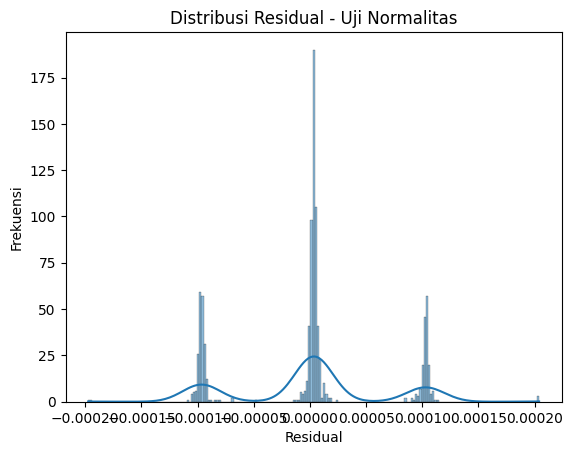

Statistik: 4.1706, p-value: 0.1243

=== Kesimpulan Uji Normalitas Residu (Uji Jarque-Bera) ===
 Residual berdistribusi normal (Gagal tolak H0).


In [ ]:
# Ambil residual dari model regresi
residuals = model.resid

# Plot distribusi residual
sns.histplot(residuals, kde=True)
plt.title("Distribusi Residual - Uji Normalitas")
plt.xlabel("Residual")
plt.ylabel("Frekuensi")
plt.show()

# Uji Jarque-Bera
jb_test = sm.stats.jarque_bera(residuals)
print(f"Statistik: {jb_test[0]:.4f}, p-value: {jb_test[1]:.4f}")

print("\n=== Kesimpulan Uji Normalitas Residu (Uji Jarque-Bera) ===")
# Interpretasi hasil
if jb_test[1] > 0.05:
    print(" Residual berdistribusi normal (Gagal tolak H0).")
else:
    print(" Residual tidak berdistribusi normal (Tolak H0).")


### Hasil Uji
- **Statistik JB** : 4.1706  
- **p-value** : 0.1243  

### Kesimpulan
Karena nilai **p-value (0.1243) > 0.05**, maka **gagal menolak H₀**.  
Dengan demikian, **residual berdistribusi normal**, sehingga asumsi normalitas pada model regresi **telah terpenuhi**.

---

### Interpretasi
Distribusi residual yang normal menunjukkan bahwa:
- Model regresi sudah **layak digunakan** untuk inferensi statistik (pengujian t dan F).  
- Estimasi parameter (koefisien regresi) yang diperoleh **tidak bias** dan memiliki **varian minimum (BLUE: Best Linear Unbiased Estimator)**.  
- Nilai prediksi dari model dapat dianggap **stabil dan reliabel** terhadap sampel yang dianalisis.  

Dengan terpenuhinya asumsi ini, kamu dapat melanjutkan ke pengujian asumsi klasik lainnya seperti **multikolinearitas**, **heteroskedastisitas**, dan **autokorelasi** untuk memastikan keseluruhan model regresi bersifat valid dan efisien.


## Multikolinearitas (VIF)


### Tujuan
Uji multikolinearitas bertujuan untuk memastikan bahwa **tidak terdapat korelasi tinggi antar variabel independen** dalam model regresi.  
Jika dua atau lebih variabel bebas (X) memiliki korelasi yang kuat, maka:
- Model akan kesulitan membedakan pengaruh masing-masing variabel terhadap variabel dependen (Y),
- Nilai koefisien regresi menjadi tidak stabil, dan
- Standard error meningkat, sehingga uji signifikansi (t-test dan F-test) bisa menyesatkan.

---
### Kriteria Penilaian

| Nilai VIF | Interpretasi |
|:--:|:--|
| **VIF < 5** | Tidak ada multikolinearitas yang serius |
| **VIF ≥ 5** | Terdapat indikasi multikolinearitas tinggi |

> Catatan:  
> Beberapa literatur juga menggunakan batas yang lebih ketat, seperti **VIF > 5** sudah dianggap menunjukkan gejala multikolinearitas sedang.

---

In [ ]:
# Uji Multikolinearitas (VIF)
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_const.values, i)
                   for i in range(X_train_const.shape[1])]

print("=== Uji Multikolinearitas (VIF) ===")
print(vif_data)
print("\n=== Kesimpulan per Variabel ===")

# Interpretasi hasil VIF
for index, row in vif_data.iterrows():
    feature = row["feature"]
    vif_value = row["VIF"]
    if vif_value < 5:
        print(f"✅ {feature}: Tidak ada indikasi multikolinearitas (VIF = {vif_value:.2f})")
    elif 5 <= vif_value < 10:
        print(f"⚠️ {feature}: Ada indikasi multikolinearitas sedang (VIF = {vif_value:.2f})")
    else:
        print(f"❌ {feature}: Multikolinearitas tinggi (VIF = {vif_value:.2f})")

# Kesimpulan umum
if all(vif_data["VIF"] < 10):
    print("\n✅ Secara keseluruhan, model bebas dari multikolinearitas serius.")
else:
    print("\n⚠️ Ditemukan variabel dengan multikolinearitas tinggi — periksa kembali variabel tersebut.")


=== Uji Multikolinearitas (VIF) ===
      feature       VIF
0       const  1.711357
1  Z_Score_X1  1.019549
2  Z_Score_X2  1.380078
3  Z_Score_X3  1.374649
4  Z_Score_X4  1.009363

=== Kesimpulan per Variabel ===
✅ const: Tidak ada indikasi multikolinearitas (VIF = 1.71)
✅ Z_Score_X1: Tidak ada indikasi multikolinearitas (VIF = 1.02)
✅ Z_Score_X2: Tidak ada indikasi multikolinearitas (VIF = 1.38)
✅ Z_Score_X3: Tidak ada indikasi multikolinearitas (VIF = 1.37)
✅ Z_Score_X4: Tidak ada indikasi multikolinearitas (VIF = 1.01)

✅ Secara keseluruhan, model bebas dari multikolinearitas serius.


## Uji Multikolinearitas (VIF)

| No | Variabel     | VIF       | Keterangan |
|----|---------------|-----------|-------------|
| 1  | const         | 1.711357  | Tidak ada indikasi multikolinearitas |
| 2  | Z_Score_X1    | 1.019549  | Tidak ada indikasi multikolinearitas |
| 3  | Z_Score_X2    | 1.380078  | Tidak ada indikasi multikolinearitas |
| 4  | Z_Score_X3    | 1.374649  | Tidak ada indikasi multikolinearitas |
| 5  | Z_Score_X4    | 1.009363  | Tidak ada indikasi multikolinearitas |

---

### Kesimpulan
Berdasarkan hasil perhitungan **Variance Inflation Factor (VIF)** untuk setiap variabel independen:
- Seluruh nilai VIF berada **di bawah 5**, bahkan jauh di bawah batas umum sudah sangat baik).  
- Hal ini menunjukkan bahwa **tidak terdapat masalah multikolinearitas** antar variabel independen dalam model regresi.

Dengan demikian, model **bebas dari multikolinearitas serius**, dan setiap variabel independen memberikan kontribusi yang **unik serta tidak redundant** terhadap variabel dependen.

---

### Interpretasi
Apabila hasil uji VIF menunjukkan bahwa **multikolinearitas tidak terjadi (VIF rendah)**, maka:

1. **Hubungan antar variabel independen tidak saling kuat**, sehingga model tidak mengalami distorsi dalam estimasi koefisien regresi.  
2. **Koefisien regresi (β)** menjadi lebih stabil dan dapat dipercaya, karena tidak dipengaruhi oleh hubungan linear antar variabel bebas.  
3. Model mampu **menggambarkan pengaruh masing-masing variabel independen secara akurat** terhadap variabel dependen.  
4. Proses interpretasi terhadap pengaruh tiap variabel menjadi **lebih valid secara statistik**.


## Heteroskedastisitas (Breusch-Pagan)

**Tujuan:**
Untuk mengetahui apakah varian residual konstan (homoskedastis) atau tidak.
Kalau varian residual berubah-ubah seiring nilai prediksi, maka ada heteroskedastisitas, yang membuat estimasi tidak efisien.

### Tujuan
Uji heteroskedastisitas dilakukan untuk mengetahui apakah **varian residual dalam model regresi bersifat konstan (homoskedastis)** atau **berubah-ubah (heteroskedastis)** terhadap nilai variabel independen.

Jika varians residual tidak konstan, maka model dikatakan mengalami **heteroskedastisitas**, yang dapat menyebabkan:
- Estimasi koefisien tetap **tidak bias**, namun menjadi **tidak efisien**.
- Nilai **standard error** menjadi tidak akurat, sehingga **uji t dan F** tidak valid.

---

### Metode Pengujian
Uji yang digunakan adalah **Breusch–Pagan Test (BP Test)**.

**Hipotesis:**
- H₀ : Tidak ada heteroskedastisitas (varian residual konstan)
- H₁ : Ada heteroskedastisitas (varian residual tidak konstan)

---

### Kriteria Keputusan
Uji ini menghasilkan dua jenis statistik uji dan *p-value*:

| Jenis Uji | Distribusi Acuan | Keterangan |
|:--|:--|:--|
| **LM-Test p-value** | Chi-Square (χ²) | Umumnya digunakan untuk jumlah sampel besar |
| **F-Test p-value** | Distribusi F | Lebih stabil untuk sampel kecil-menengah |

**Kriteria pengambilan keputusan:**
- Jika *LM-Test p-value* > 0.05 → ✅ Tidak ada heteroskedastisitas  
- Jika *LM-Test p-value* ≤ 0.05 → ❌ Terdapat indikasi heteroskedastisitas

In [ ]:
# Heteroskedastisitas (Breusch-Pagan Test)
bp_test = het_breuschpagan(residuals, X_train_const)
labels = ['LM Stat','LM-Test p-value','F-Stat','F-Test p-value']
print("\n=== Uji Heteroskedastisitas (Breusch-Pagan) ===")
bp_result = dict(zip(labels, bp_test))
print(bp_result)

print("\n=== Kesimpulan Uji Heteroskedastisitas (Breusch-Pagan) ===")

if bp_result['LM-Test p-value'] > 0.05:
    print("✅ Tidak ada heteroskedastisitas (p > 0.05)")
else:
    print("❌ Ada indikasi heteroskedastisitas (p ≤ 0.05)")


=== Uji Heteroskedastisitas (Breusch-Pagan) ===
{'LM Stat': np.float64(4.993598514791936), 'LM-Test p-value': np.float64(0.2879549584938026), 'F-Stat': np.float64(1.2483910448560789), 'F-Test p-value': np.float64(0.2887819226685588)}

=== Kesimpulan Uji Heteroskedastisitas (Breusch-Pagan) ===
✅ Tidak ada heteroskedastisitas (p > 0.05)


## Uji Heteroskedastisitas (Breusch-Pagan)

| Statistik Uji | Nilai | Keterangan |
|----------------|--------|-------------|
| LM Stat | 4.9936 | Statistik Lagrange Multiplier |
| LM-Test p-value | 0.2879 | p-value uji LM |
| F-Stat | 1.2484 | Statistik F |
| F-Test p-value | 0.2888 | p-value uji F |

---

### Kesimpulan
Berdasarkan hasil **Uji Breusch-Pagan**, diperoleh nilai **p-value sebesar 0.2879 (p > 0.05)**.  
Sehingga dapat disimpulkan bahwa:

> **Gagal menolak H₀**, artinya **tidak terdapat heteroskedastisitas** dalam model regresi.

Dengan demikian, model memenuhi asumsi **homoskedastisitas**, yaitu varians error (residual) bersifat konstan pada setiap nilai variabel independen.

---

### Interpretasi
Apabila hasil uji menunjukkan bahwa **tidak terdapat heteroskedastisitas**, maka:

1. **Varians residual bersifat konstan (homoskedastisitas)** di seluruh observasi.  
2. Estimasi parameter model (koefisien regresi) yang diperoleh **bersifat efisien dan tidak bias** (BLUE — Best Linear Unbiased Estimator).  
3. Uji signifikansi seperti **uji t dan uji F** dapat **dipercaya validitasnya**, karena tidak terdistorsi oleh ketidakkonstanan varians.  
4. Model regresi dapat diinterpretasikan dengan **tingkat keandalan yang lebih tinggi**, tanpa perlu transformasi tambahan pada data.  

> Kesimpulannya, hasil ini menunjukkan bahwa model regresi yang digunakan **sudah memenuhi asumsi klasik heteroskedastisitas**.


## Autokorelasi (Durbin-Watson)

### Tujuan
Uji autokorelasi dilakukan untuk mendeteksi apakah terdapat **korelasi antara residual pada observasi yang berurutan** dalam suatu model regresi.  
Autokorelasi sering muncul pada **data runtun waktu (time series)**, di mana kesalahan (error) pada periode tertentu berkaitan dengan kesalahan pada periode sebelumnya.

Jika residual saling berkorelasi, maka asumsi **independensi residual** dilanggar, sehingga:
- Nilai estimasi koefisien regresi tetap **tidak bias**,  
  tetapi **uji statistik (t dan F)** menjadi tidak valid.  
- Model kehilangan keandalan dalam melakukan inferensi.
---

### Kriteria Penilaian

| Nilai DW | Interpretasi |
|:--:|:--|
| Mendekati **2** | Tidak ada autokorelasi |
| **< 1.5** | Ada indikasi autokorelasi positif |
| **> 2.5** | Ada indikasi autokorelasi negatif |

> Catatan:  
> Nilai DW berada pada rentang antara **0 hingga 4**.  
> Semakin jauh nilai DW dari 2, semakin kuat indikasi adanya autokorelasi.

---


In [ ]:
print("Durbin-Watson:", sm.stats.durbin_watson(residuals))

print("\n=== Kesimpulan Uji Auto Korelasi (Durbin Watson) ===")
if sm.stats.durbin_watson(residuals) < 1.5:
    print("❌ Ada indikasi autokorelasi positif")
    print("❌ Tidak memenuhi asumsi independensi residual")
elif sm.stats.durbin_watson(residuals) > 2.5:
    print("❌ Ada indikasi autokorelasi negatif")
    print("❌ Tidak memenuhi asumsi independensi residual")
    print("❌ Tidak efisien")
else:
    print("✅ Tidak ada autokorelasi")

Durbin-Watson: 1.9393749070395974

=== Kesimpulan Uji Auto Korelasi (Durbin Watson) ===
✅ Tidak ada autokorelasi


# Hasil Uji Autokorelasi (Durbin-Watson)
## Uji Autokorelasi (Durbin-Watson)

| Statistik Uji | Nilai | Keterangan |
|----------------|--------|-------------|
| Durbin-Watson | 1.939 | Nilai mendekati 2 menandakan tidak ada autokorelasi |

---

### Kesimpulan
Berdasarkan hasil **Uji Durbin-Watson (DW = 1.939)**, nilai ini berada **dekat dengan angka 2**,  
yang menunjukkan bahwa:

> **Tidak terdapat autokorelasi** antar residual dalam model regresi.  
> Dengan kata lain, **Gagal menolak H₀** (tidak ada korelasi antara residual periode ke-t dan periode sebelumnya).

---

### Interpretasi
Apabila hasil uji menunjukkan **tidak ada autokorelasi**, maka:

1. **Residual (kesalahan prediksi)** antar observasi bersifat **independen (tidak saling berkorelasi)**.  
2. Model regresi tidak mengandung pola sistematis pada error — artinya model sudah menangkap hubungan antar variabel dengan baik.  
3. Estimasi parameter regresi yang dihasilkan bersifat **efisien**, sehingga hasil uji statistik seperti **uji t** dan **uji F** dapat dipercaya.  
4. Model layak digunakan untuk **prediksi dan inferensi**, terutama pada data runtun waktu (time series) maupun data berurutan.

> Kesimpulannya, hasil ini menunjukkan bahwa **model regresi bebas dari masalah autokorelasi**,  
> sehingga asumsi klasik mengenai independensi error **telah terpenuhi**.


# Contoh Prediksi Data


Perbandingan Nilai Aktual dan Prediksi:
      Aktual  Prediksi
626   2.7776  2.777693
220   6.4759  6.475797
678   2.0712  2.071096
1075  4.5894  4.589393
174  -3.3069 -3.306904


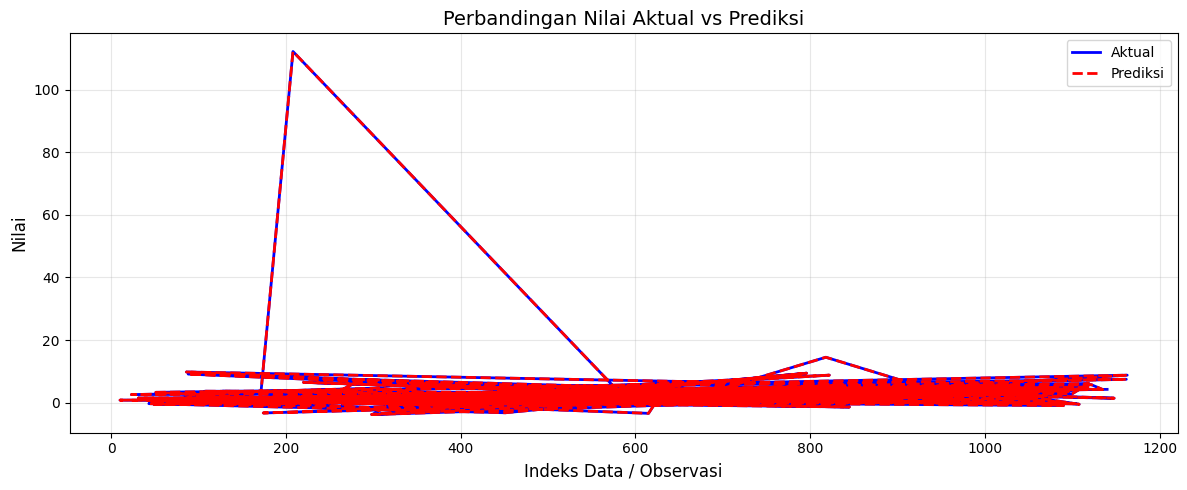

In [ ]:
y_pred = model.predict(X_test_const)
perbandingan = pd.DataFrame({"Aktual": y_test, "Prediksi": y_pred})
print("\nPerbandingan Nilai Aktual dan Prediksi:")
print(perbandingan.head())

# Line Plot dengan indeks asli sebagai sumbu-x
plt.figure(figsize=(12, 5))
plt.plot(perbandingan.index, perbandingan["Aktual"], label="Aktual", color="blue", linewidth=2)
plt.plot(perbandingan.index, perbandingan["Prediksi"], label="Prediksi", color="red", linestyle="--", linewidth=2)

plt.title("Perbandingan Nilai Aktual vs Prediksi", fontsize=14)
plt.xlabel("Indeks Data / Observasi", fontsize=12)
plt.ylabel("Nilai", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretasi Line Chart dan Hasil Evaluasi Model

Berdasarkan line chart perbandingan nilai aktual dan prediksi:

- Garis **Prediksi** hampir **menempel sepenuhnya pada garis Aktual**, menunjukkan model menangkap tren data dengan sangat baik.
- Tidak terlihat deviasi signifikan antara prediksi dan nilai aktual pada seluruh observasi.
- Hal ini konsisten dengan hasil evaluasi model:
  - **R-squared ≈ 1** → model mampu menjelaskan hampir 100% variasi data.
  - **MAE, MSE, RMSE sangat mendekati 0** → kesalahan prediksi sangat kecil.
  - **MAPE ≈ 0.01%** → persentase kesalahan relatif hampir nihil.

### Kesimpulan
Model regresi ini memiliki **performansi prediksi yang sangat akurat**.  
Line chart yang menempel rapat pada garis aktual memperkuat interpretasi bahwa prediksi hampir identik dengan nilai asli.


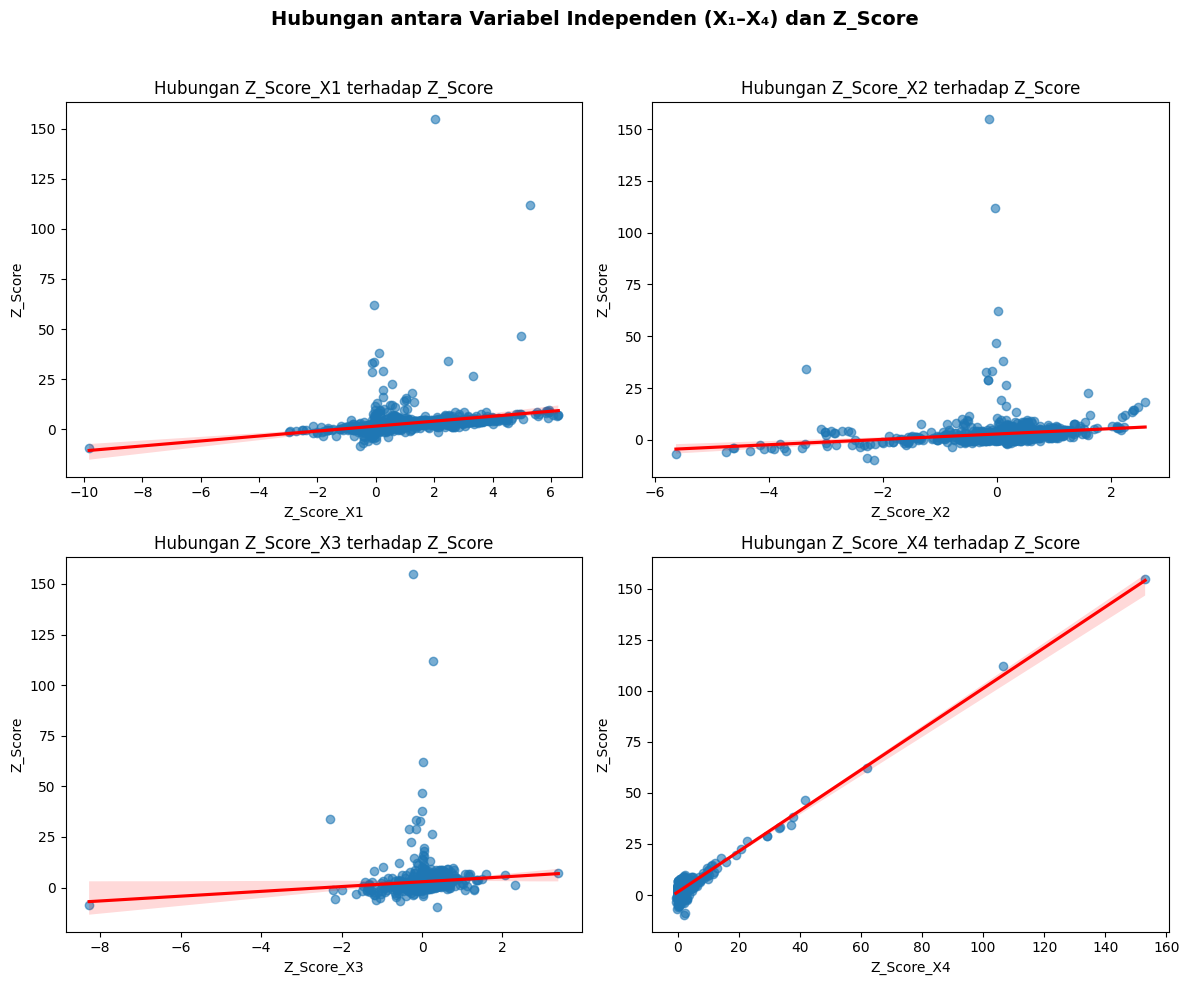

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Hubungan antara Variabel Independen (X₁–X₄) dan Z_Score', fontsize=14, fontweight='bold')

indep_vars = ['Z_Score_X1', 'Z_Score_X2', 'Z_Score_X3', 'Z_Score_X4']

for i, var in enumerate(indep_vars):
    ax = axes[i//2, i%2]
    sns.regplot(x=var, y='Z_Score', data=rg, ax=ax,
                line_kws={"color": "red"}, scatter_kws={'alpha': 0.6})
    ax.set_title(f'Hubungan {var} terhadap Z_Score')
    ax.set_xlabel(var)
    ax.set_ylabel('Z_Score')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Ringkasan Komprehensif Hubungan Variabel Independen Terhadap $Z\_Score$

Analisis ini bertujuan untuk memahami seberapa besar dan bagaimana masing-masing variabel independen (dari $Z\_Score\_X1$ hingga $Z\_Score\_X4$) memengaruhi variabel dependen ($Z\_Score$). Kami menggunakan **matriks korelasi** (nilai $r$) untuk mengukur kekuatan dan arah hubungan secara kuantitatif, serta **regression plot** sebagai bukti visual.

Secara umum, hubungan antara variabel independen dan $Z\_Score$ sangat timpang. **Satu variabel mendominasi, sementara tiga lainnya memiliki peran yang sangat kecil.**

---

### Penjelasan Per Variabel: Siapa Berkontribusi dan Siapa Tidak?

#### 1. $Z\_Score\_X4$ (Si Paling Penting / **The Dominator**)

| Metrik | Deskripsi | Nilai/Keterangan |
| :--- | :--- | :--- |
| **Korelasi ($r$)** | Kekuatan Hubungan | **Sangat Kuat** ($r = 0.9534$) |
| **Arah** | Positif | Sejalan (naik bersama) |
| **Visualisasi** | Titik-titik data hampir membentuk garis lurus yang menanjak. |

**Interpretasi:**
Variabel ini adalah **faktor penentu utama** dari $Z\_Score$. Nilai korelasi yang sangat kuat menunjukkan bahwa **perubahan pada $Z\_Score\_X4$ hampir selalu diikuti oleh perubahan yang sebanding pada $Z\_Score$** dengan arah yang sama. Dalam model prediksi, $Z\_Score\_X4$ memiliki kontribusi yang paling krusial.

---

#### 2. $Z\_Score\_X1$ (Si Kontributor Kecil)

| Metrik | Deskripsi | Nilai/Keterangan |
| :--- | :--- | :--- |
| **Korelasi ($r$)** | Kekuatan Hubungan | **Lemah** ($r = 0.2763$) |
| **Arah** | Positif | Sejalan (sedikit naik bersama) |
| **Visualisasi** | Garis tren sedikit menanjak, namun titik-titik data **sangat menyebar** jauh dari garis. |

**Interpretasi Komprehensif:**
Variabel ini memang memiliki **pengaruh positif**, namun dampaknya **sangat kecil** (lemah). Penyebaran titik data menunjukkan bahwa hanya sebagian kecil dari variasi pada $Z\_Score$ yang dapat dijelaskan oleh $Z\_Score\_X1$. Kontribusinya terhadap model prediksi adalah minimal.

---

#### 3. $Z\_Score\_X2$ dan $Z\_Score\_X3$ (Si Hampir Tidak Berpengaruh / **The Minor Players**)

| Variabel | Korelasi ($r$) | Kekuatan Hubungan | Visualisasi (Plot) |
| :--- | :--- | :--- | :--- |
| $Z\_Score\_X2$ | $0.1646$ | Sangat Lemah | Garis tren hampir datar |
| $Z\_Score\_X3$ | $0.0816$ | Sangat Lemah | Garis tren hampir datar |

**Interpretasi:**
Kedua variabel ini secara praktis **hampir tidak memiliki hubungan linear** dengan $Z\_Score$. Nilai korelasi yang sangat mendekati nol menunjukkan bahwa perubahan pada $Z\_Score\_X2$ atau $Z\_Score\_X3$ **tidak dapat digunakan** untuk memprediksi perubahan pada $Z\_Score$. Kontribusi mereka terhadap kemampuan model untuk menjelaskan atau memprediksi $Z\_Score$ adalah **minimal, bahkan bisa diabaikan.**

---

### Kesimpulan Umum Model Regresi

1.  **Variabel Kunci:** **Hanya $Z\_Score\_X4$** yang memberikan dasar kuat dan tepercaya untuk menjelaskan $Z\_Score$. Model regresi secara efektif **hampir hanya mengandalkan variabel ini.**
2.  **Variabel Tidak Relevan (Linear):** $Z\_Score\_X1$, $Z\_Score\_X2$, dan $Z\_Score\_X3$ adalah **variabel lemah** dalam konteks hubungan linear.
3.  **Rekomendasi:** Dalam tahap penyempurnaan model, variabel $Z\_Score\_X2$ dan $Z\_Score\_X3$ harus dipertimbangkan untuk **dihilangkan** jika tujuannya adalah membuat model yang lebih sederhana dan efisien, karena mereka tidak menambah daya prediksi yang signifikan.
4.  **Konsistensi Data:** Hasil visualisasi regression plot **sepenuhnya konsisten** dengan nilai korelasi kuantitatif.


=== Perbandingan Kategori Aktual vs Prediksi ===
      Aktual  Prediksi  Aktual_Kategori  Prediksi_Kategori
626   2.7776  2.777693                2                  2
220   6.4759  6.475797                2                  2
678   2.0712  2.071096                1                  1
1075  4.5894  4.589393                2                  2
174  -3.3069 -3.306904                0                  0

=== Perbandingan Kategori dengan Keterangan ===
      Aktual  Prediksi  Aktual_Kategori  Prediksi_Kategori Aktual_Keterangan  \
626   2.7776  2.777693                2                  2              Aman   
220   6.4759  6.475797                2                  2              Aman   
678   2.0712  2.071096                1                  1         Grey Area   
1075  4.5894  4.589393                2                  2              Aman   
174  -3.3069 -3.306904                0                  0  Potensi Bangkrut   

     Prediksi_Keterangan  
626                 Aman  
220         

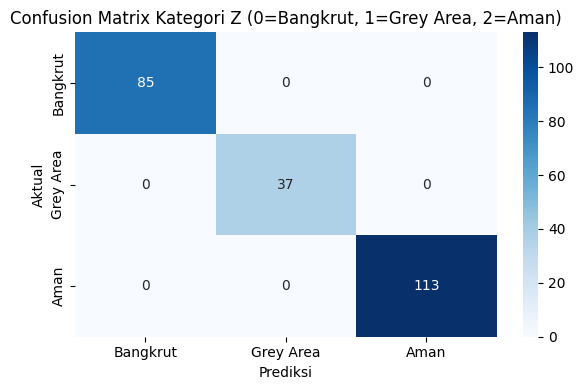

In [ ]:
#Kategorisasi Hasil Prediksi Z dan Evaluasi Klasifikasi
# ==============================================================
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Fungsi kategorisasi
def kategorikan_z(z):
    if z < 1.1:
        return 0  # Potensi Bangkrut
    elif 1.2 <= z <= 2.6:
        return 1  # Grey Area
    else:
        return 2  # Aman

# Terapkan ke data aktual & prediksi
perbandingan["Aktual_Kategori"] = perbandingan["Aktual"].apply(kategorikan_z)
perbandingan["Prediksi_Kategori"] = perbandingan["Prediksi"].apply(kategorikan_z)

print("\n=== Perbandingan Kategori Aktual vs Prediksi ===")
print(perbandingan.head())

kategori_label = {
    0: "Potensi Bangkrut",
    1: "Grey Area",
    2: "Aman"
}

# Buat kolom keterangan
perbandingan["Aktual_Keterangan"] = perbandingan["Aktual_Kategori"].map(kategori_label)
perbandingan["Prediksi_Keterangan"] = perbandingan["Prediksi_Kategori"].map(kategori_label)

print("\n=== Perbandingan Kategori dengan Keterangan ===")
print(perbandingan[["Aktual", "Prediksi", "Aktual_Kategori", "Prediksi_Kategori",
                    "Aktual_Keterangan", "Prediksi_Keterangan"]].head())

# Evaluasi Klasifikasi
cm = confusion_matrix(perbandingan["Aktual_Kategori"], perbandingan["Prediksi_Kategori"])
accuracy = accuracy_score(perbandingan["Aktual_Kategori"], perbandingan["Prediksi_Kategori"])
precision = precision_score(perbandingan["Aktual_Kategori"], perbandingan["Prediksi_Kategori"], average='weighted')
recall = recall_score(perbandingan["Aktual_Kategori"], perbandingan["Prediksi_Kategori"], average='weighted')
f1 = f1_score(perbandingan["Aktual_Kategori"], perbandingan["Prediksi_Kategori"], average='weighted')

print("\n=== Evaluasi Klasifikasi Berdasarkan Kategori Z ===")
print(f"Akurasi  : {accuracy:.4f}")
print(f"Presisi  : {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# Confusion Matrix
cm_df = pd.DataFrame(cm,
                     index=["Bangkrut", "Grey Area", "Aman"],
                     columns=["Bangkrut", "Grey Area", "Aman"])
print("\nConfusion Matrix:")
print(cm_df)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix Kategori Z (0=Bangkrut, 1=Grey Area, 2=Aman)")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()



## Evaluasi Hasil Prediksi ##

B erikut interpretasi berdasarkan hasil evaluasi model regresi logistik berganda terhadap kategori Z_Score (0 = Bangkrut, 1 = Grey Area, 2 = Aman), :



1.   Perbandingan Nilai Aktual dan Prediksi


*  Kolom Aktual menunjukkan nilai sebenarnya dari data, sedangkan kolom Prediksi menunjukkan hasil estimasi dari model regresi.
*   CKolom Aktual_Kategori dan Prediksi_Kategori mengelompokkan hasil tersebut ke dalam kategori yang sesuai, yaitu:
    * 0 = Potensi Bangkrut

    * 1 = Grey Area

    * 2 = Aman

* Dari tabel hasil prediksi, terlihat bahwa nilai aktual dan nilai prediksi memiliki kesesuaian kategori yang sempurna.
    * Data dengan nilai aktual 2.7776 menghasilkan prediksi 2.777693, keduanya termasuk dalam kategori Aman.
    * Hasil serupa juga terjadi pada data dengan kategori Grey Area dan Potensi Bangkrut, yang menunjukkan konsistensi prediksi model.

2.   Confusion Matrix


*   Confusion Matrix menunjukkan bahwa seluruh data berhasil diklasifikasikan dengan benar tanpa kesalahan. Nilai diagonal utama menggambarkan jumlah prediksi yang benar untuk setiap kategori, yaitu:
    * 85 data Potensi Bangkrut
    * 37 data Grey Area
    * 113 data Aman
*   Hasil ini menunjukkan bahwa model memiliki kemampuan yang sangat baik dalam mengenali pola dan membedakan antar kategori.



